# TAHAP 3

### Subbab 3.1 — Import pustaka

Memuat library yang dibutuhkan untuk tahap ini.


In [14]:
import os
import pandas as pd
import numpy as np
import json
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split # For splitting data
import nltk
import re

### Subbab 3.2 — Import pustaka

Memuat library yang dibutuhkan untuk tahap ini.


In [15]:
# Untuk BERT (jika dipilih)
# !pip install transformers sentence-transformers > /dev/null 2>&1 # sentence-transformers is often easier untuk embeddings
import torch
from transformers import AutoTokenizer, AutoModel
# dari sentence_transformers import SentenceTransformer # Alternative untuk easier embeddings

# from google.colab import drive

### Subbab 3.3 — Import pustaka

Memuat library yang dibutuhkan untuk tahap ini.


In [16]:
# Untuk BERT (jika dipilih)
# !pip install transformers sentence-transformers > /dev/null 2>&1 # sentence-transformers is often easier untuk embeddings
import torch
from transformers import AutoTokenizer, AutoModel
# dari sentence_transformers import SentenceTransformer # Alternative untuk easier embeddings

# from google.colab import drive
import nltk # Import NLTK here as well if used in this cell
import re # Import re if used in this cell

# --- Bagian Konfigurasi ---
# !!! IMPORTANT: Ensure these path match your Google Drive structure
# dan output dari Notebook 2 !!!
BASE_DRIVE_PATH = ".." # Changed from colab path to local relative path

# Path untuk input processed data dari Notebook 2
PATH_PROCESSED_INPUT = os.path.join(BASE_DRIVE_PATH, "data/processed")
PROCESSED_CSV_FILENAME = "cases_processed.csv" # Assuming this is the output from N2

# Path untuk evaluation data output
PATH_EVAL_OUTPUT = os.path.join(BASE_DRIVE_PATH, "data/eval")
os.makedirs(PATH_EVAL_OUTPUT, exist_ok=True)
QUERIES_JSON_FILENAME = "queries.json"

# BERT Model (example)
BERT_MODEL_NAME = 'indobenchmark/indobert-base-p1'
# Or menggunakan SentenceTransformer: 'paraphrase-multilingual-MiniLM-L12-v2' or an Indonesian specific one jika available

# Determine device untuk PyTorch (BERT)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# --- Pengaturan NLTK (untuk prapemrosesan jika diperlukan) ---
try:
    nltk.data.find('tokenizers/punkt')
  # Catch LookupError specifically jika a resource is not found
    try:
         nltk.data.find('corpora/stopwords')
    except LookupError:
         print("NLTK 'stopwords' not found. Downloading...")
         nltk.download('stopwords', quiet=True)
         print("NLTK 'stopwords' downloaded.")
except LookupError:
  # Blok ini menangani kondisi saat resource 'punkt' tidak ditemukan
    print("NLTK 'punkt' not found. Downloading...")
    nltk.download('punkt', quiet=True)
    print("NLTK 'punkt' downloaded.")
except Exception as e:
     print(f"An unexpected error occurred during NLTK setup: {e}")

# saat ini, safely muat stopwords
indonesian_stopwords = nltk.corpus.stopwords.words('indonesian')

Using device: cuda
NLTK 'stopwords' not found. Downloading...
NLTK 'stopwords' downloaded.


### Subbab 3.4 — Fungsi bantu

Berisi fungsi utilitas yang dipakai ulang pada proses inti.


In [17]:
def preprocess_text_for_tfidf(text):
    """Prapemrosesan dasar untuk TF-IDF: huruf kecil, hapus tanda baca, hapus stopword."""
    if pd.isna(text) or not text:
        return ""
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
    words = nltk.word_tokenize(text)
    words = [word for word in words if word not in indonesian_stopwords and word.isalpha()]
    return " ".join(words)

def load_processed_data(filepath):
    """Memuat CSV data terproses."""
    try:
        df = pd.read_csv(filepath)
        print(f"Successfully loaded processed data from: {filepath} with shape {df.shape}")
    # Pastikan kolom teks yang dipakai untuk retrieval tidak semuanya NaN
    # Choose one: 'text_full', 'ringkasan_fakta', 'argumen_hukum_utama'
    # Untuk this example, let's use 'ringkasan_fakta' as it's more concise than 'text_full'
    # dan potentially more focused than 'argumen_hukum_utama' untuk general similarity.
    # Or, you can combine them.
        if 'ringkasan_fakta' in df.columns and df['ringkasan_fakta'].isna().all():
            print("Warning: 'ringkasan_fakta' is all NaN. Falling back to 'text_full'.")
            df['retrieval_text_source'] = df['text_full']
        elif 'ringkasan_fakta' in df.columns:
            df['retrieval_text_source'] = df['ringkasan_fakta']
        else:
            print("Warning: 'ringkasan_fakta' not found. Using 'text_full'.")
            df['retrieval_text_source'] = df['text_full']

    # Tangani nilai NaN pada teks sumber terpilih dengan mengisi string kosong
        df['retrieval_text_source'] = df['retrieval_text_source'].fillna('')

        return df
    except FileNotFoundError:
        print(f"Error: Processed data file not found at {filepath}. Please run Notebook 2 first.")
        return None
    except Exception as e:
        print(f"Error loading processed data: {e}")
        return None

### Subbab 3.5 — Proses inti

Bagian ini menjalankan:  Tahap 3.a: Representasi Vektor .


In [18]:
# --- Tahap 3.a: Representasi Vektor ---

# Opsi 1: TF-IDF
print("\n--- Initializing TF-IDF Components ---")
tfidf_vectorizer = TfidfVectorizer(preprocessor=preprocess_text_for_tfidf, max_df=0.95, min_df=2, ngram_range=(1,2))
# max_df: abaikan term yang muncul di lebih dari 95% dokumen
# min_df: ignore terms that appear in less than 2 documents
# ngram_range: consider unigrams dan bigrams

# Global variables ke store fitted vectorizer dan kasus vectors untuk TF-IDF
fitted_tfidf_vectorizer = None
case_vectors_tfidf = None
case_ids_global_tfidf = None # To store the case_ids corresponding to case_vectors_tfidf



--- Initializing TF-IDF Components ---


### Subbab 3.6 — Proses inti

Bagian ini menjalankan: Option 2: BERT Embeddings.


In [19]:
# Opsi 2: Embedding BERT
print("\n--- Initializing BERT Components ---")
try:
    bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
    bert_model = AutoModel.from_pretrained(BERT_MODEL_NAME).to(DEVICE)
    bert_model.eval() # Set model to evaluation mode
    print(f"BERT model '{BERT_MODEL_NAME}' loaded successfully.")
except Exception as e:
    print(f"Could not load BERT model '{BERT_MODEL_NAME}': {e}. BERT retrieval will not be available.")
    bert_tokenizer = None
    bert_model = None

# Global variables untuk BERT embeddings
case_embeddings_bert = None # To store NumPy array of embeddings
case_ids_global_bert = None # To store the case_ids corresponding to case_embeddings_bert
BERT_EMBEDDING_DIM = 768 # For indobert-base models


--- Initializing BERT Components ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BERT model 'indobenchmark/indobert-base-p1' loaded successfully.


### Subbab 3.7 — Definisi beberapa fungsi

Mendefinisikan beberapa fungsi utama yang dipakai pada tahap ini.


In [20]:
def get_bert_embedding(text, tokenizer, model, device, max_length=512):
    """Membuat embedding untuk teks menggunakan model BERT pralatih."""
    if not tokenizer or not model:
        return np.zeros(BERT_EMBEDDING_DIM) # Return zero vector if model not loaded

    # Preprocess: BERT has its own tokenizer, typically minimal cleaning like whitespace norm.
    text = str(text).strip()
    if not text: # Handle empty string
        return np.zeros(BERT_EMBEDDING_DIM)

    inputs = tokenizer(text, return_tensors='pt', max_length=max_length, truncation=True, padding='max_length')
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs);
    # Gunakan embedding token [CLS]
    cls_embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy().squeeze()
    return cls_embedding

def fit_vector_models(df_cases):
    """Melatih TF-IDF dan membuat embedding BERT untuk basis kasus."""
    global fitted_tfidf_vectorizer, case_vectors_tfidf, case_ids_global_tfidf
    global case_embeddings_bert, case_ids_global_bert

    if df_cases is None or df_cases.empty:
        print("DataFrame is empty. Cannot fit vector models.")
        return

    print("\n[Fitting TF-IDF Vectorizer...]")
    # Gunakan kolom 'retrieval_text_source' yang disiapkan pada load_processed_data
    # Ensure there are no NaNs by filling dengan empty string (already done in muat_processed_data)
    texts_for_tfidf = df_cases['retrieval_text_source'].tolist()
    try:
        case_vectors_tfidf = tfidf_vectorizer.fit_transform(texts_for_tfidf)
        fitted_tfidf_vectorizer = tfidf_vectorizer
        case_ids_global_tfidf = df_cases['case_id'].tolist()
        print(f"TF-IDF fitting complete. Shape of case_vectors_tfidf: {case_vectors_tfidf.shape}")
    except Exception as e:
        print(f"Error fitting TF-IDF: {e}")


    print("\n[Generating BERT Embeddings... (this may take a while)]")
    if bert_model and bert_tokenizer:
    # Ensure 'retrieval_text_source' is used, dan it's clean
        texts_for_bert = df_cases['retrieval_text_source'].tolist()
        embeddings_list = []
        for i, text in enumerate(texts_for_bert):
            # Give some progress feedback
            if (i + 1) % 10 == 0 or i == len(texts_for_bert) - 1:
                print(f"  Generating BERT embedding for document {i+1}/{len(texts_for_bert)}...")
            embedding = get_bert_embedding(text, bert_tokenizer, bert_model, DEVICE)
            embeddings_list.append(embedding)

        if embeddings_list:
            case_embeddings_bert = np.array(embeddings_list)
            case_ids_global_bert = df_cases['case_id'].tolist()
            print(f"BERT embeddings generation complete. Shape: {case_embeddings_bert.shape}")
        else:
            print("No BERT embeddings were generated.")
    else:
        print("BERT model not loaded. Skipping BERT embedding generation.")

### Subbab 3.8 — Definisi fungsi `retrieve_cases`

Mendefinisikan fungsi `retrieve_cases` untuk kebutuhan proses pada tahap ini.


In [21]:
# --- Tahap 3.c: Fungsi Retrieval ---
# As per PDF: def retrieve(query: str, k: int = 5) -> List[case_id]

def retrieve_cases(query_text, retrieval_method="tfidf", k=5):
    """
    Retrieves top-k similar case IDs for a given query text.
    Methods: "tfidf" or "bert".
    """
    if retrieval_method == "tfidf":
        if fitted_tfidf_vectorizer is None or case_vectors_tfidf is None:
            print("TF-IDF model not fitted. Please run `fit_vector_models` first.")
            return []
    # Preprocess query same way as documents
        processed_query = preprocess_text_for_tfidf(query_text)
        query_vector = fitted_tfidf_vectorizer.transform([processed_query])
        similarities = cosine_similarity(query_vector, case_vectors_tfidf).flatten()
    # Get top-k indices
        top_k_indices = similarities.argsort()[-k:][::-1]
        top_k_case_ids = [case_ids_global_tfidf[i] for i in top_k_indices]
        top_k_scores = [similarities[i] for i in top_k_indices]
        print(f"Retrieved using TF-IDF. Scores: {top_k_scores}")
        return top_k_case_ids

    elif retrieval_method == "bert":
        if case_embeddings_bert is None or not bert_model:
            print("BERT embeddings not generated or model not loaded. Please run `fit_vector_models` or check BERT setup.")
            return []
        query_embedding = get_bert_embedding(query_text, bert_tokenizer, bert_model, DEVICE)
        query_embedding = query_embedding.reshape(1, -1) # Reshape for cosine_similarity
        similarities = cosine_similarity(query_embedding, case_embeddings_bert).flatten()
        top_k_indices = similarities.argsort()[-k:][::-1]
        top_k_case_ids = [case_ids_global_bert[i] for i in top_k_indices]
        top_k_scores = [similarities[i] for i in top_k_indices]
        print(f"Retrieved using BERT. Scores: {top_k_scores}")
        return top_k_case_ids
    else:
        print(f"Unknown retrieval_method: {retrieval_method}. Choose 'tfidf' or 'bert'.")
        return []

### Subbab 3.8b — Splitting Data (Train/Test 80:20)

Membagi data menjadi **data train** dan **data test** dengan rasio **80:20** sesuai instruksi tugas. Data train digunakan untuk melatih SVM dan Naive Bayes, data test untuk evaluasi.


In [22]:
# --- Tahap 3.b: Splitting Data Train/Test (80:20) ---
from sklearn.model_selection import train_test_split

# Global untuk dipakai lintas sel
df_train_global = None
df_test_global  = None

def split_cases(df_input, test_size=0.2, random_state=42):
    """
    Split DataFrame kasus menjadi train & test.
    Stratifikasi pada amar_kategori jika setiap kelas >= 2 sampel.
    Rasio default: 80:20.
    """
    global df_train_global, df_test_global

    if len(df_input) < 5:
        print('⚠️  Data terlalu sedikit, semua dipakai sebagai train.')
        df_train_global = df_input.copy()
        df_test_global  = df_input.copy()
        return df_train_global, df_test_global

    strat = None
    if 'amar_kategori' in df_input.columns:
        counts = df_input['amar_kategori'].value_counts()
        if counts.min() >= 2:
            strat = df_input['amar_kategori']

    df_train_global, df_test_global = train_test_split(
        df_input, test_size=test_size,
        random_state=random_state, stratify=strat
    )

    ratio_train = int((1 - test_size) * 100)
    ratio_test  = int(test_size * 100)
    print(f'\n✅ Splitting selesai — rasio {ratio_train}:{ratio_test}')
    print(f'   Train : {len(df_train_global)} kasus')
    print(f'   Test  : {len(df_test_global)} kasus')

    if 'amar_kategori' in df_train_global.columns:
        print('\nDistribusi label TRAIN:')
        print(df_train_global['amar_kategori'].value_counts().to_string())
        print('\nDistribusi label TEST:')
        print(df_test_global['amar_kategori'].value_counts().to_string())

    return df_train_global, df_test_global


print('✅ Fungsi split_cases berhasil didefinisikan.')


✅ Fungsi split_cases berhasil didefinisikan.


### Subbab 3.8c — Model ML: SVM & Naive Bayes di atas TF-IDF

Melatih **Support Vector Machine (SVM)** dan **Naive Bayes** pada representasi TF-IDF untuk *classification/retrieval* sesuai instruksi tugas (poin c.ii.1). Label klasifikasi = `amar_kategori`. TF-IDF di-fit **hanya pada data train** untuk menghindari data leakage.


In [23]:
# --- Tahap 3.c: SVM & Naive Bayes pada TF-IDF ---
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.svm import SVC
from sklearn.naive_bayes import ComplementNB
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer as TfidfVectorizerClf
from sklearn.metrics import (
    classification_report, accuracy_score,
    precision_recall_fscore_support
)
from sklearn.metrics.pairwise import cosine_similarity as cos_sim_clf

# Globals
svm_model      = None
nb_model       = None
label_encoder_clf = LabelEncoder()
tfidf_for_clf  = None   # Fit hanya pada train


def train_ml_classifiers(df_train, df_test,
                          text_col='retrieval_text_source',
                          label_col='amar_kategori'):
    """
    Melatih SVM (linear) dan Naive Bayes (ComplementNB) pada TF-IDF.
    TF-IDF hanya di-fit pada df_train (no data leakage).
    Evaluasi dilakukan pada df_test.
    """
    global svm_model, nb_model, label_encoder_clf, tfidf_for_clf

    # Fallback kolom teks
    for col in [text_col, 'retrieval_text_source', 'text_full', 'ringkasan_fakta']:
        if col in df_train.columns:
            text_col = col
            break

    if label_col not in df_train.columns:
        print(f'❌ Kolom "{label_col}" tidak ada. Pastikan Tahap 2 sudah dijalankan.')
        return None

    X_train_raw = df_train[text_col].fillna('').tolist()
    X_test_raw  = df_test[text_col].fillna('').tolist()
    FALLBACK_LABEL = 'Lain-lain (Perlu Cek Manual)'
    y_train_raw = df_train[label_col].fillna(FALLBACK_LABEL).tolist()
    y_test_raw  = df_test[label_col].fillna(FALLBACK_LABEL).tolist()

    # Encode label
    label_encoder_clf.fit(y_train_raw + y_test_raw)
    y_train = label_encoder_clf.transform(y_train_raw)
    y_test  = label_encoder_clf.transform(y_test_raw)
    print(f'\nKelas label   : {list(label_encoder_clf.classes_)}')
    print(f'Jumlah train  : {len(X_train_raw)}')
    print(f'Jumlah test   : {len(X_test_raw)}')

    # TF-IDF fit HANYA pada train
    tfidf_for_clf = TfidfVectorizerClf(
        preprocessor=preprocess_text_for_tfidf,
        max_df=0.95, min_df=1, ngram_range=(1, 2)
    )
    X_train_vec = tfidf_for_clf.fit_transform(X_train_raw)
    X_test_vec  = tfidf_for_clf.transform(X_test_raw)

    results = {}

    # ── SVM (kernel linear) ──────────────────────────────
    print('\n' + '='*55)
    print('🔵 Training SVM (kernel=linear, C=1.0)...')
    svm_model = SVC(kernel='linear', C=1.0,
                    probability=True, random_state=42)
    svm_model.fit(X_train_vec, y_train)
    y_pred_svm = svm_model.predict(X_test_vec)
    acc_svm    = accuracy_score(y_test, y_pred_svm)
    print(f'Accuracy SVM  : {acc_svm:.4f}')
    print(classification_report(
        label_encoder_clf.inverse_transform(y_test),
        label_encoder_clf.inverse_transform(y_pred_svm),
        zero_division=0
    ))
    results['SVM (TF-IDF)'] = {'accuracy': acc_svm,
                                'y_test': y_test,
                                'y_pred': y_pred_svm}

    # ── Naive Bayes (ComplementNB) ───────────────────────
    print('='*55)
    print('🟠 Training Naive Bayes (ComplementNB, alpha=0.5)...')
    nb_model = ComplementNB(alpha=0.5)
    nb_model.fit(X_train_vec, y_train)
    y_pred_nb = nb_model.predict(X_test_vec)
    acc_nb    = accuracy_score(y_test, y_pred_nb)
    print(f'Accuracy NB   : {acc_nb:.4f}')
    print(classification_report(
        label_encoder_clf.inverse_transform(y_test),
        label_encoder_clf.inverse_transform(y_pred_nb),
        zero_division=0
    ))
    results['Naive Bayes (TF-IDF)'] = {'accuracy': acc_nb,
                                        'y_test': y_test,
                                        'y_pred': y_pred_nb}

    # ── Visualisasi SVM vs NB ───────────────────────────
    model_names, accs, precs, recs, f1s = [], [], [], [], []
    for name, res in results.items():
        p, r, f, _ = precision_recall_fscore_support(
            res['y_test'], res['y_pred'],
            average='weighted', zero_division=0
        )
        model_names.append(name)
        accs.append(round(res['accuracy'], 4))
        precs.append(round(p, 4))
        recs.append(round(r, 4))
        f1s.append(round(f, 4))

    x     = np.arange(len(model_names))
    width = 0.18
    fig, ax = plt.subplots(figsize=(11, 6))
    bars = [
        ax.bar(x - 1.5*width, accs,  width, label='Accuracy',  color='#2196F3', edgecolor='black'),
        ax.bar(x - 0.5*width, precs, width, label='Precision', color='#4CAF50', edgecolor='black'),
        ax.bar(x + 0.5*width, recs,  width, label='Recall',    color='#FF9800', edgecolor='black'),
        ax.bar(x + 1.5*width, f1s,   width, label='F1-Score',  color='#E91E63', edgecolor='black'),
    ]
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=11)
    ax.set_ylim(0, 1.2)
    ax.set_ylabel('Score')
    ax.set_title('Perbandingan SVM vs Naive Bayes — TF-IDF Classification',
                 fontsize=13, fontweight='bold')
    ax.legend(loc='upper right')
    ax.yaxis.grid(True, linestyle='--', alpha=0.6)
    for bar_group in bars:
        ax.bar_label(bar_group, fmt='%.2f', fontsize=8, padding=2)
    plt.tight_layout()
    chart_path = os.path.join(PATH_EVAL_OUTPUT, 'svm_nb_comparison_chart.png')
    plt.savefig(chart_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\n✅ Grafik perbandingan disimpan ke: {chart_path}')

    # ── Simpan metrik ke CSV ────────────────────────────
    import pandas as pd
    df_metrics = pd.DataFrame({
        'model'              : model_names,
        'accuracy'           : accs,
        'precision_weighted' : precs,
        'recall_weighted'    : recs,
        'f1_weighted'        : f1s,
    })
    metrics_path = os.path.join(PATH_EVAL_OUTPUT, 'svm_nb_metrics.csv')
    df_metrics.to_csv(metrics_path, index=False, encoding='utf-8')
    print(f'✅ Metrik SVM/NB disimpan ke: {metrics_path}')
    display(df_metrics)
    return results


def predict_with_classifier(query_text, model_choice='svm', k=5,
                             df_cases_full=None):
    """
    Retrieval hybrid via classifier:
    1. Prediksi kategori amar query (SVM atau NB)
    2. Filter kasus dengan kategori sama
    3. Ranking cosine-similarity TF-IDF → return top-k case_id
    """
    global svm_model, nb_model, tfidf_for_clf, label_encoder_clf
    import pandas as pd

    model = svm_model if model_choice == 'svm' else nb_model
    if model is None or tfidf_for_clf is None:
        print(f'⚠️  Model {model_choice.upper()} belum dilatih.')
        return []

    q_vec     = tfidf_for_clf.transform([preprocess_text_for_tfidf(query_text)])
    pred_int  = model.predict(q_vec)[0]
    pred_cat  = label_encoder_clf.inverse_transform([pred_int])[0]
    print(f'  [{model_choice.upper()}] Prediksi kategori: "{pred_cat}"')

    if df_cases_full is None or df_cases_full.empty:
        return []

    # Filter kasus kategori sama, fallback ke semua jika kosong
    if 'amar_kategori' in df_cases_full.columns:
        subset = df_cases_full[df_cases_full['amar_kategori'] == pred_cat]
        if subset.empty:
            subset = df_cases_full
    else:
        subset = df_cases_full

    # Pilih kolom teks
    txt_col = next(
        (c for c in ['retrieval_text_source', 'text_full', 'ringkasan_fakta']
         if c in subset.columns), None
    )
    if txt_col is None:
        return []

    vecs = tfidf_for_clf.transform(subset[txt_col].fillna('').tolist())
    sims = cos_sim_clf(q_vec, vecs).flatten()
    top_idx = sims.argsort()[::-1][:k]
    return [subset.iloc[i]['case_id'] for i in top_idx]


print('✅ Fungsi train_ml_classifiers & predict_with_classifier berhasil didefinisikan.')


✅ Fungsi train_ml_classifiers & predict_with_classifier berhasil didefinisikan.


### Subbab 3.9 — Definisi fungsi `create_and_save_sample_queries`

Mendefinisikan fungsi `create_and_save_sample_queries` untuk kebutuhan proses pada tahap ini.


In [24]:
# --- Tahap 3.b: Pembagian Data ---
# Seluruh dataset digunakan sebagai case base.
# Sample queries di bawah dipakai sebagai test set untuk evaluasi retrieval.

# --- Tahap 3.d: Pengujian Awal & queries.json ---
def create_and_save_sample_queries(filepath, df_cases_full=None):
    """
    Membuat sample queries dan menyimpannya ke file JSON.
    ground_truth_ids diisi OTOMATIS menggunakan retrieval TF-IDF:
      → top-3 case_id dengan similarity tertinggi untuk setiap query.
    ground_truth_solution diisi OTOMATIS dari kolom amar_kategori
      → diambil dari case dengan similarity tertinggi (rank 1).
    """
    sample_queries_data = [
        {"query_id": "Q001_PJK",
         "query_text": "Sengketa Pajak Pertambahan Nilai (PPN) atas koreksi penyerahan ekspor karena adanya transaksi dengan pihak afiliasi"},
        {"query_id": "Q002_PJK",
         "query_text": "Koreksi Pajak Masukan pada perusahaan perkebunan kelapa sawit terpadu yang menghasilkan Tandan Buah Segar (TBS) untuk diolah sendiri menjadi CPO"},
        {"query_id": "Q003_PJK",
         "query_text": "Koreksi DPP PPN berdasarkan ekualisasi antara peredaran usaha dengan penerimaan uang pada rekening koran bank"},
        {"query_id": "Q004_PJK",
         "query_text": "Sengketa pemungutan PPh Pasal 22 atas pembelian bahan baku untuk keperluan industri dari pedagang pengumpul"},
        {"query_id": "Q005_PJK",
         "query_text": "Pengenaan PPN atas pendapatan non air seperti biaya pemasangan sambungan baru pada Perusahaan Air Minum (PDAM)"},
        {"query_id": "Q006_PJK",
         "query_text": "Sengketa tarif PPh Pasal 26 atas pembayaran bunga ke luar negeri terkait penerapan Perjanjian Penghindaran Pajak Berganda (P3B)"},
        {"query_id": "Q007_PJK",
         "query_text": "Sengketa pengkreditan Pajak Masukan karena hasil konfirmasi dari lawan transaksi dinyatakan tidak ada oleh kantor pajak"},
        {"query_id": "Q008_PJK",
         "query_text": "Sengketa koreksi biaya bunga pinjaman karena dianggap bukan biaya fiskal oleh pemeriksa pajak dalam penghitungan PPh Badan"},
        {"query_id": "Q009_PJK",
         "query_text": "Sengketa Pajak Pertambahan Nilai atas jasa konstruksi yang dikerjakan oleh kontraktor dalam proyek pembangunan fasilitas industri"},
        {"query_id": "Q010_PJK",
         "query_text": "Koreksi harga pokok penjualan dan persediaan akhir yang menyebabkan perbedaan penghasilan kena pajak antara wajib pajak dan fiskus"},
    ]

    # ── Isi otomatis ground_truth_ids & ground_truth_solution via TF-IDF ──
    GT_K = 3  # ambil top-3 sebagai pseudo ground truth
    SIMILARITY_THRESHOLD = 0.05  # minimal skor agar dianggap relevan

    can_auto_fill = (
        fitted_tfidf_vectorizer is not None
        and case_vectors_tfidf is not None
        and df_cases_full is not None
        and not df_cases_full.empty
    )

    if can_auto_fill:
        from sklearn.metrics.pairwise import cosine_similarity as cos_sim
        print(f'\n🔍 Mengisi ground_truth_ids otomatis (top-{GT_K} via TF-IDF, threshold={SIMILARITY_THRESHOLD})...')

        # Kolom amar untuk ground_truth_solution
        solution_col = None
        for col in ['amar_kategori', 'amar_putusan']:
            if col in df_cases_full.columns:
                solution_col = col
                break

        for q in sample_queries_data:
            processed_q = preprocess_text_for_tfidf(q['query_text'])
            q_vec = fitted_tfidf_vectorizer.transform([processed_q])
            sims  = cos_sim(q_vec, case_vectors_tfidf).flatten()

            # Ambil top-GT_K dengan skor di atas threshold
            top_idx   = sims.argsort()[::-1][:GT_K]
            top_ids   = [
                case_ids_global_tfidf[i]
                for i in top_idx
                if sims[i] >= SIMILARITY_THRESHOLD
            ]
            top_scores = [round(float(sims[i]), 4) for i in top_idx if sims[i] >= SIMILARITY_THRESHOLD]

            q['ground_truth_ids'] = top_ids
            q['gt_similarity_scores'] = top_scores  # simpan untuk referensi

            # ground_truth_solution dari kasus paling mirip (rank-1)
            if top_ids and solution_col:
                best_case_id = top_ids[0]
                sol_series = df_cases_full.loc[
                    df_cases_full['case_id'] == best_case_id, solution_col
                ]
                sol_val = sol_series.iloc[0] if not sol_series.empty else ''
                # Bersihkan nilai kosong atau placeholder
                q['ground_truth_solution'] = (
                    str(sol_val).strip()
                    if sol_val and str(sol_val).strip() not in ['', 'nan', 'None', 'Amar Tidak Ditemukan']
                    else 'Lain-lain (Perlu Cek Manual)'
                )
            else:
                q['ground_truth_solution'] = 'Lain-lain (Perlu Cek Manual)'

            print(f"  {q['query_id']}: gt_ids={top_ids}, skor={top_scores}, "
                  f"gt_solution='{q['ground_truth_solution']}'")

        filled = sum(1 for q in sample_queries_data if q['ground_truth_ids'])
        print(f'\n✅ {filled}/{len(sample_queries_data)} query berhasil diisi ground truth otomatis.')
        if filled < len(sample_queries_data):
            print('   Query yang gt_ids-nya masih [] artinya tidak ada kasus dengan similarity >= threshold.')
            print(f'   Coba turunkan SIMILARITY_THRESHOLD (saat ini {SIMILARITY_THRESHOLD}) atau tambah lebih banyak PDF.')
    else:
        # Tidak bisa auto-fill → set kosong dengan pesan
        for q in sample_queries_data:
            q['ground_truth_ids'] = []
            q['ground_truth_solution'] = ''
        print('⚠️  TF-IDF belum di-fit atau df_cases kosong. ground_truth_ids tidak bisa diisi otomatis.')
        print('   Pastikan fit_vector_models(df_cases) sudah dijalankan sebelum fungsi ini.')

    try:
        with open(filepath, 'w', encoding='utf-8') as f:
            json.dump(sample_queries_data, f, indent=4, ensure_ascii=False)
        print(f'\n💾 queries.json disimpan ke: {filepath}')
    except Exception as e:
        print(f'Error menyimpan queries.json: {e}')

    return sample_queries_data


### Subbab 3.10 — Eksekusi utama tahap

Menjalankan alur utama tahap ini secara berurutan.


TAHAP 3: Case Retrieval — MULAI
Starting Tahap 3: Case Retrieval
Mounted at /content/drive
Successfully loaded processed data from: /content/drive/MyDrive/Penalaran Komputer/Penugasan_Sub_CPMK_3/CBR8/data/processed/cases_processed.csv with shape (43, 25)
[Tahap 3.1] Fitting TF-IDF dan BERT vector models...

[Fitting TF-IDF Vectorizer...]
TF-IDF fitting complete. Shape of case_vectors_tfidf: (43, 217)

[Generating BERT Embeddings... (this may take a while)]
  Generating BERT embedding for document 10/43...
  Generating BERT embedding for document 20/43...
  Generating BERT embedding for document 30/43...
  Generating BERT embedding for document 40/43...
  Generating BERT embedding for document 43/43...
BERT embeddings generation complete. Shape: (43, 768)
[Tahap 3.1] TF-IDF shape: (43, 217)
[Tahap 3.1] BERT embeddings shape: (43, 768)
[Tahap 3.2] Splitting Data Train/Test 80:20...

[3. Splitting Data Train/Test 80:20]

✅ Splitting selesai — rasio 80:20
   Train : 34 kasus
   Test  : 9 k

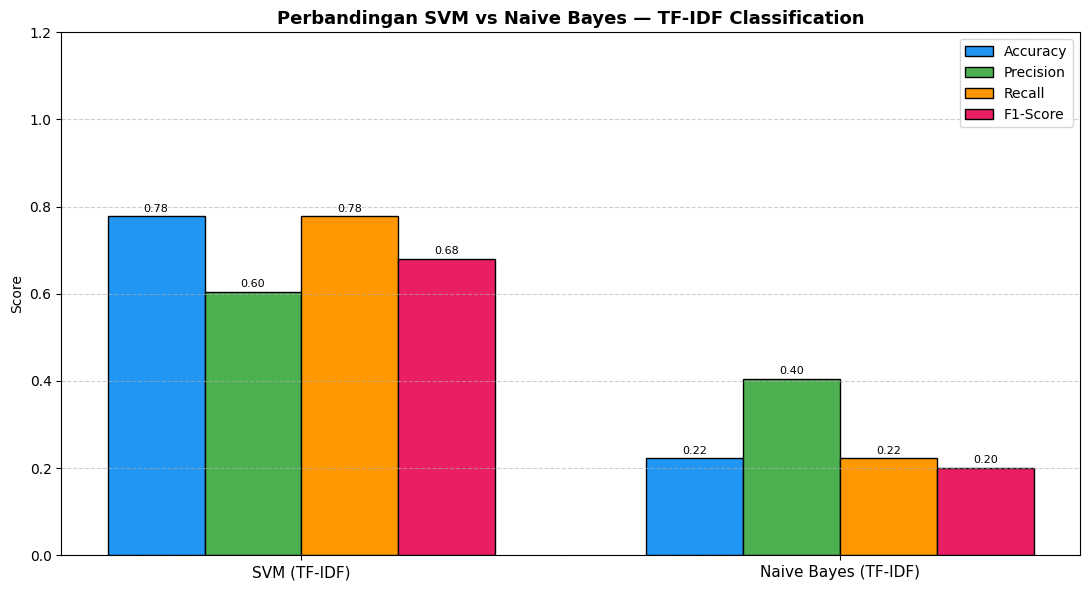


✅ Grafik perbandingan disimpan ke: /content/drive/MyDrive/Penalaran Komputer/Penugasan_Sub_CPMK_3/CBR8/data/eval/svm_nb_comparison_chart.png
✅ Metrik SVM/NB disimpan ke: /content/drive/MyDrive/Penalaran Komputer/Penugasan_Sub_CPMK_3/CBR8/data/eval/svm_nb_metrics.csv


,model,accuracy,precision_weighted,recall_weighted,f1_weighted
0,SVM (TF-IDF),0.7778,0.6049,0.7778,0.6806
1,Naive Bayes (TF-IDF),0.2222,0.4048,0.2222,0.2006


[Tahap 3.3] SVM & Naive Bayes training selesai.
[Tahap 3.4] Membuat dan menyimpan queries.json...

🔍 Mengisi ground_truth_ids otomatis (top-3 via TF-IDF, threshold=0.05)...
  Q001_PJK: gt_ids=['case_017', 'case_006', 'case_014'], skor=[0.264, 0.2453, 0.2141], gt_solution='Menolak permohonan'
  Q002_PJK: gt_ids=['case_002', 'case_012', 'case_003'], skor=[0.4506, 0.2188, 0.2088], gt_solution='Menolak permohonan'
  Q003_PJK: gt_ids=['case_006', 'case_019', 'case_040'], skor=[0.3686, 0.2734, 0.1464], gt_solution='Menolak permohonan'
  Q004_PJK: gt_ids=['case_013', 'case_014', 'case_033'], skor=[0.1518, 0.148, 0.1408], gt_solution='Mengabulkan seluruhnya'
  Q005_PJK: gt_ids=['case_013', 'case_017', 'case_043'], skor=[0.1563, 0.1282, 0.118], gt_solution='Mengabulkan seluruhnya'
  Q006_PJK: gt_ids=['case_029', 'case_041', 'case_013'], skor=[0.2515, 0.2182, 0.1774], gt_solution='Mengabulkan seluruhnya'
  Q007_PJK: gt_ids=['case_002', 'case_029', 'case_013'], skor=[0.4962, 0.4368, 0.3087], gt_s

,case_id,no_perkara,retrieval_text_source
5,case_006,1477/B/PK/PJK/2017 PUTUSAN Nomor 1477/B/PK/PJK...,Bahwa yang menjadi pokok sengketa dalam permoh...
13,case_014,1731/B/PK/PJK/2016 PUTUSAN Nomor 1731/B/PK/PJK...,Bahwa merujuk pada Keputusan Terbanding Nomor ...
16,case_017,186/B/PK/PJK/2017 PUTUSAN Nomor 186/B/PK/PJK/2...,; Bahwa yang menjadi pokok sengketa dalam perm...



Retrieving top 3 using BERT...
Retrieved using BERT. Scores: [np.float64(0.9369090776298316), np.float64(0.793303460991371), np.float64(0.786138609309402)]
BERT Retrieved Case IDs: ['case_013', 'case_033', 'case_019']


,case_id,no_perkara,retrieval_text_source
12,case_013,1697/C/PK/PJK/2016TFR PUTUSAN Nomor 1697/C/PK/...,Bahwa yang menjadi pokok sengketa dalam permoh...
18,case_019,2125/B/PK/PJK/2017TFR PUTUSAN Nomor 2125/B/PK/...,Bahwa yang menjadi pokok sengketa dalam permoh...
32,case_033,351/B/PK/PJK/2017 PUTUSAN Nomor 351/B/PK/PJK/2...,Bahwa yang menjadi pokok sengketa dalam permoh...



--- Ringkasan queries.json yang dihasilkan ---
  Q001_PJK: gt_ids=['case_017', 'case_006', 'case_014'], gt_solution='Menolak permohonan'
  Q002_PJK: gt_ids=['case_002', 'case_012', 'case_003'], gt_solution='Menolak permohonan'
  Q003_PJK: gt_ids=['case_006', 'case_019', 'case_040'], gt_solution='Menolak permohonan'
  Q004_PJK: gt_ids=['case_013', 'case_014', 'case_033'], gt_solution='Mengabulkan seluruhnya'
  Q005_PJK: gt_ids=['case_013', 'case_017', 'case_043'], gt_solution='Mengabulkan seluruhnya'
  Q006_PJK: gt_ids=['case_029', 'case_041', 'case_013'], gt_solution='Mengabulkan seluruhnya'
  Q007_PJK: gt_ids=['case_002', 'case_029', 'case_013'], gt_solution='Menolak permohonan'
  Q008_PJK: gt_ids=['case_013', 'case_033', 'case_029'], gt_solution='Mengabulkan seluruhnya'
  Q009_PJK: gt_ids=['case_017', 'case_006', 'case_011'], gt_solution='Menolak permohonan'
  Q010_PJK: gt_ids=['case_029', 'case_002', 'case_017'], gt_solution='Mengabulkan seluruhnya'
TAHAP 3: Case Retrieval — SELESA

In [25]:
# --- Logika Eksekusi Utama Tahap 3 ---
log_cleaning_action("=" * 60)
log_cleaning_action("TAHAP 3: Case Retrieval — MULAI")
log_cleaning_action("=" * 60)
print('Starting Tahap 3: Case Retrieval')
# drive.mount('/content/drive', force_remount=True)

# 1. Muat Data
processed_data_filepath = os.path.join(PATH_PROCESSED_INPUT, PROCESSED_CSV_FILENAME)
df_cases = load_processed_data(processed_data_filepath)

if df_cases is not None and not df_cases.empty:
    # 2. Fit Vector Models (TF-IDF dan/or BERT)
    log_cleaning_action("[Tahap 3.1] Fitting TF-IDF dan BERT vector models...")
    fit_vector_models(df_cases)
    log_cleaning_action(f"[Tahap 3.1] TF-IDF shape: {case_vectors_tfidf.shape if case_vectors_tfidf is not None else 'N/A'}")
    log_cleaning_action(f"[Tahap 3.1] BERT embeddings shape: {case_embeddings_bert.shape if case_embeddings_bert is not None else 'N/A'}")

    # 3. Split data train/test (80:20)
    log_cleaning_action("[Tahap 3.2] Splitting Data Train/Test 80:20...")
    print('\n[3. Splitting Data Train/Test 80:20]')
    df_train_global, df_test_global = split_cases(df_cases, test_size=0.2)
    log_cleaning_action(f"[Tahap 3.2] Train: {len(df_train_global)} kasus, Test: {len(df_test_global)} kasus")

    # 4. Latih SVM dan Naive Bayes
    log_cleaning_action("[Tahap 3.3] Training SVM & Naive Bayes pada TF-IDF...")
    print('\n[4. Training SVM & Naive Bayes pada TF-IDF]')
    if df_train_global is not None and not df_train_global.empty:
        # Pastikan kolom retrieval_text_source ada
        if 'retrieval_text_source' not in df_train_global.columns:
            rc = 'ringkasan_fakta' if 'ringkasan_fakta' in df_train_global.columns else 'text_full'
            df_train_global['retrieval_text_source'] = df_train_global[rc].fillna('')
            df_test_global['retrieval_text_source']  = df_test_global[rc].fillna('')
        ml_results = train_ml_classifiers(df_train_global, df_test_global)
        log_cleaning_action("[Tahap 3.3] SVM & Naive Bayes training selesai.")
    else:
        print('⚠️  Data train kosong, SVM/NB tidak bisa dilatih.')

    # 5. Buat & Simpan queries.json (ground_truth diisi OTOMATIS setelah fit)
    queries_json_filepath = os.path.join(PATH_EVAL_OUTPUT, QUERIES_JSON_FILENAME)
    log_cleaning_action("[Tahap 3.4] Membuat dan menyimpan queries.json...")
    sample_queries = create_and_save_sample_queries(queries_json_filepath, df_cases)
    log_cleaning_action(f"[Tahap 3.4] queries.json disimpan: {queries_json_filepath}")

    # 6. Uji fungsi retrieval dengan query pertama
    print('\n--- Testing Retrieval Function ---')
    if sample_queries:
        test_query_text = sample_queries[0]['query_text']
        k_results = 3
        print(f"\nQuery: '{test_query_text}'")

        if fitted_tfidf_vectorizer:
            print(f'\nRetrieving top {k_results} using TF-IDF...')
            retrieved_ids_tfidf = retrieve_cases(test_query_text, retrieval_method='tfidf', k=k_results)
            print(f'TF-IDF Retrieved Case IDs: {retrieved_ids_tfidf}')
            if retrieved_ids_tfidf:
                display(df_cases[df_cases['case_id'].isin(retrieved_ids_tfidf)]
                        [['case_id', 'no_perkara', 'retrieval_text_source']].head())

        if case_embeddings_bert is not None:
            print(f'\nRetrieving top {k_results} using BERT...')
            retrieved_ids_bert = retrieve_cases(test_query_text, retrieval_method='bert', k=k_results)
            print(f'BERT Retrieved Case IDs: {retrieved_ids_bert}')
            if retrieved_ids_bert:
                display(df_cases[df_cases['case_id'].isin(retrieved_ids_bert)]
                        [['case_id', 'no_perkara', 'retrieval_text_source']].head())

    # 7. Tampilkan ringkasan ground truth yang dihasilkan
    print('\n--- Ringkasan queries.json yang dihasilkan ---')
    for q in sample_queries:
        print(f"  {q['query_id']}: "
              f"gt_ids={q.get('ground_truth_ids', [])}, "
              f"gt_solution='{q.get('ground_truth_solution', '')}'")

else:
    print('Failed to load data. Cannot proceed with retrieval.')


    # 8. Uji predict_with_classifier (SVM & NB)
    if svm_model is not None and df_cases is not None:
        print(chr(10) + "="*55)
        print("[TAHAP 3.c] Uji Retrieval via Classifier (SVM & NB)")
        print("="*55)
        test_q = sample_queries[0]["query_text"] if sample_queries else "Sengketa PPN pajak masukan"
        print(f"Query uji: {test_q[:80]}")
        ids_svm = predict_with_classifier(test_q, "svm", k=5, df_cases_full=df_cases)
        print(f"Top-5 SVM : {ids_svm}")
        ids_nb = predict_with_classifier(test_q, "nb", k=5, df_cases_full=df_cases)
        print(f"Top-5 NB  : {ids_nb}")
log_cleaning_action("TAHAP 3: Case Retrieval — SELESAI")
print('\nTahap 3: Case Retrieval - Complete.')
